Loading model from my_cnn_model.h5...



Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset downloaded to: /kaggle/input/plantdisease
Searching for image data in: /kaggle/input/plantdisease

--- Smart Evaluation on /kaggle/input/plantdisease/PlantVillage ---

Mapping dataset folders to model classes...
Successfully mapped 14 folders.

Processing images (this may take a moment)...


Final Accuracy: 94.90%

--- Generating Metrics ---
Metrics saved to test_metric.json

                                        precision    recall  f1-score   support

         Pepper,_bell___Bacterial_spot       0.98      0.95      0.97       997
                Pepper,_bell___healthy       0.98      0.98      0.98      1478
                 Potato___Early_blight       0.99      0.99      0.99      1000
                  Potato___Late_blight       0.95      0.92      0.94      1000
                      Potato___healthy       0.89      0.86      0.87       152
               Tomato___Bacterial_spot       0.98      0.96     

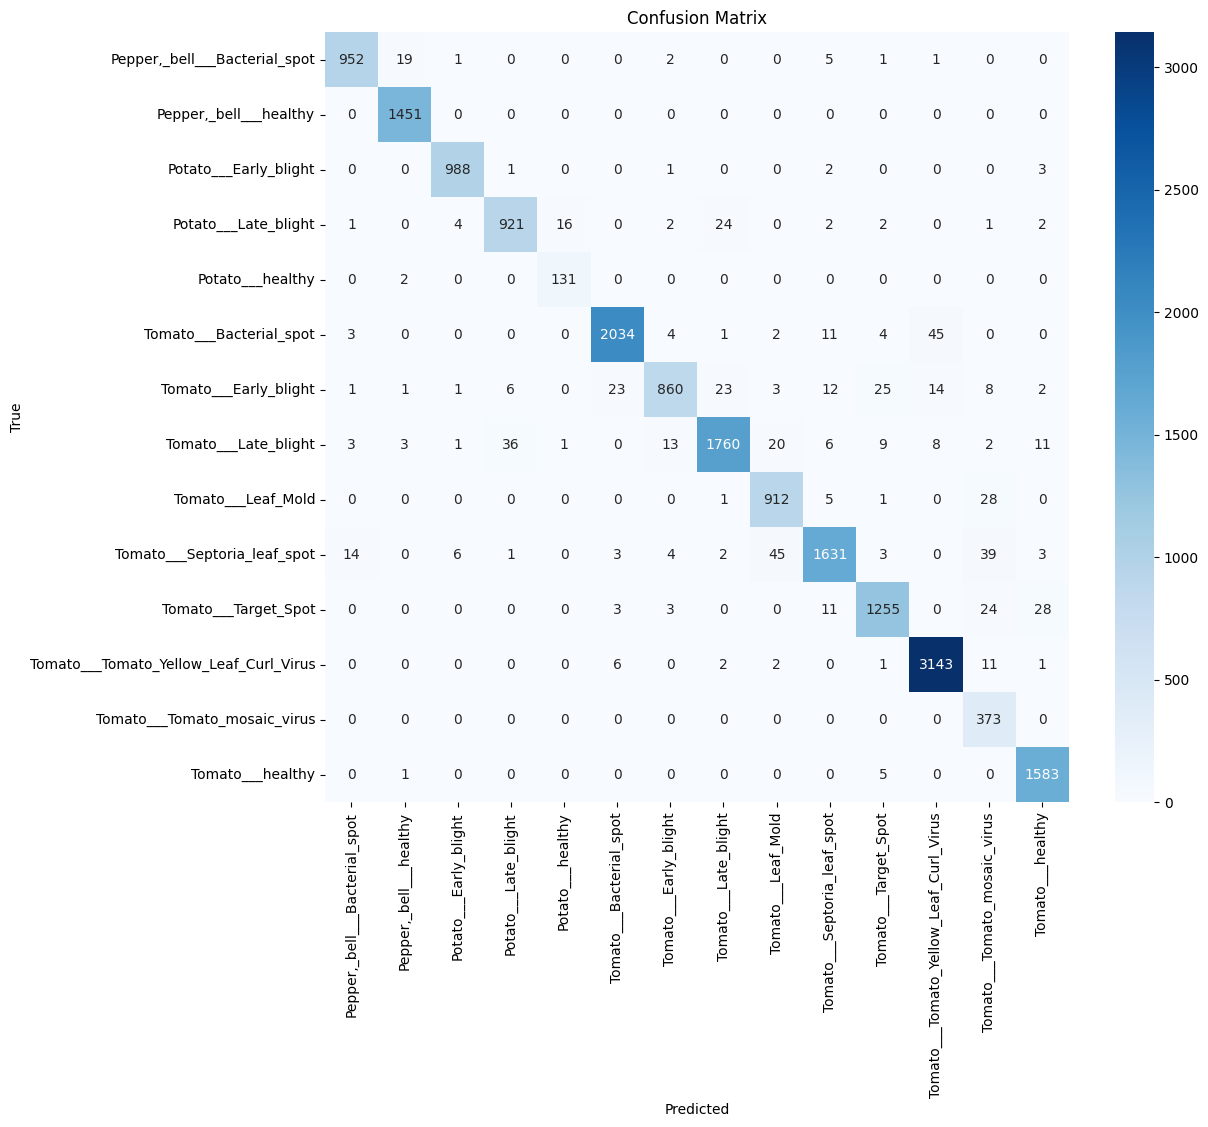

In [7]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub  # Library to download datasets
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# --- Configuration ---
MODEL_PATH = 'my_cnn_model.h5'  # Ensure this matches your trained .h5 file
IMG_SIZE = (150, 150)
JSON_OUTPUT_FILE = 'test_metric.json'
DATASET_HANDLE = 'emmarex/plantdisease' # The specific Kaggle dataset

# The 38 specific classes your model was trained on (Alphabetical Order)
# This order is CRITICAL. Do not change it.
TRAINED_CLASSES = [
    'Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy',
    'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy',
    'Corn_(maize)___Cercospora_leaf_spot_Gray_leaf_spot', 'Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot',
    'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy',
    'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy',
    'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight',
    'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy',
    'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy',
    'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites_Two-spotted_spider_mite',
    'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

def find_dataset_root(start_path):
    """
    Recursively searches for the directory actually containing the class folders.
    This handles cases where the dataset is nested like 'dataset/PlantVillage/PlantVillage/...'
    """
    print(f"Searching for image data in: {start_path}")
    for root, dirs, files in os.walk(start_path):
        # We identify the data root by checking if it contains folders that look like our classes
        # e.g., we look for 'Tomato_healthy' or 'Apple_Black_rot' (normalized)
        normalized_dirs = [d.lower().replace('_', '').replace(',', '') for d in dirs]

        # Check for a few specific known classes to confirm this is the right folder
        if 'tomatohealthy' in normalized_dirs or 'applehealthy' in normalized_dirs:
            return root

    return start_path  # Fallback to the download path if deep search fails

def predict_single_image(model, img_path):
    """Predicts class for a single image file."""
    if not os.path.exists(img_path):
        print("Error: Image not found.")
        return

    try:
        # Load and preprocess
        img = image.load_img(img_path, target_size=IMG_SIZE)
        img_arr = image.img_to_array(img)
        img_arr = np.expand_dims(img_arr, axis=0)
        img_arr = img_arr / 255.0  # Normalize

        # Predict
        predictions = model.predict(img_arr, verbose=0)
        pred_idx = np.argmax(predictions[0])
        confidence = np.max(predictions[0])
        pred_label = TRAINED_CLASSES[pred_idx]

        print(f"\n--- Prediction ---")
        print(f"Result: {pred_label}")
        print(f"Confidence: {confidence:.2%}")

        plt.imshow(img)
        plt.title(f"{pred_label} ({confidence:.0%})")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error: {e}")

def evaluate_dataset_smart(model, download_path):
    """
    Evaluates the model on a dataset even if folder names differ slightly.
    Saves results to JSON.
    """
    # 1. Find the real data folder (handle nesting)
    dataset_dir = find_dataset_root(download_path)
    print(f"\n--- Smart Evaluation on {dataset_dir} ---")

    dataset_folders = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])

    if len(dataset_folders) == 0:
        print("Error: No subdirectories found.")
        return

    # 2. Map Dataset Folders to Trained Classes
    folder_to_index = {}
    print("\nMapping dataset folders to model classes...")
    for folder in dataset_folders:
        # Normalize string for comparison (lowercase, remove underscores/commas)
        norm_folder = folder.lower().replace('_', '').replace(',', '')

        match_found = False
        for i, trained_class in enumerate(TRAINED_CLASSES):
            norm_trained = trained_class.lower().replace('_', '').replace(',', '')

            if norm_folder == norm_trained:
                folder_to_index[folder] = i
                match_found = True
                break

        if not match_found:
            # Optional: Print warning only if verbose
            pass

    if not folder_to_index:
        print("Critical Error: No folders could be matched to the model's classes.")
        return

    print(f"Successfully mapped {len(folder_to_index)} folders.")

    # 3. Iterate and Predict
    y_true = []
    y_pred = []

    print("\nProcessing images (this may take a moment)...")
    total_images = 0
    correct = 0

    for folder, true_index in folder_to_index.items():
        folder_path = os.path.join(dataset_dir, folder)
        files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        for file in files:
            img_path = os.path.join(folder_path, file)
            try:
                img = image.load_img(img_path, target_size=IMG_SIZE)
                img_arr = image.img_to_array(img)
                img_arr = np.expand_dims(img_arr, axis=0)
                img_arr = img_arr / 255.0 # Normalize

                prediction = model.predict(img_arr, verbose=0)
                pred_index = np.argmax(prediction[0])

                y_true.append(true_index)
                y_pred.append(pred_index)

                if true_index == pred_index:
                    correct += 1
                total_images += 1

                if total_images % 100 == 0:
                    print(f"Processed {total_images} images...", end='\r')

            except Exception as e:
                pass

    # 4. Results & JSON Export
    if total_images == 0:
        print("No valid images found.")
        return

    accuracy = correct / total_images
    print(f"\n\nFinal Accuracy: {accuracy:.2%}")

    print("\n--- Generating Metrics ---")
    present_indices = sorted(list(set(y_true)))
    present_names = [TRAINED_CLASSES[i] for i in present_indices]

    # Generate dictionary for JSON
    report_dict = classification_report(
        y_true,
        y_pred,
        labels=present_indices,
        target_names=present_names,
        output_dict=True
    )

    # Save to JSON
    with open(JSON_OUTPUT_FILE, 'w') as f:
        json.dump(report_dict, f, indent=4)
    print(f"Metrics saved to {JSON_OUTPUT_FILE}")

    # Print Text Report
    print("\n" + classification_report(y_true, y_pred, labels=present_indices, target_names=present_names))

    # 5. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=present_indices)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=present_names, yticklabels=present_names, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

if __name__ == "__main__":
    # 1. Load Model
    if os.path.exists(MODEL_PATH):
        print(f"Loading model from {MODEL_PATH}...")
        model = load_model(MODEL_PATH)
    else:
        print(f"Error: {MODEL_PATH} not found. Please upload your trained model.")
        exit()

    # 2. Download Dataset automatically
    print(f"\nDownloading dataset '{DATASET_HANDLE}' from Kaggle...")
    try:
        # kagglehub handles authentication via environment variables or ~/.kaggle/kaggle.json
        download_path = kagglehub.dataset_download(DATASET_HANDLE)
        print(f"Dataset downloaded to: {download_path}")

        # 3. Evaluate
        evaluate_dataset_smart(model, download_path)

    except Exception as e:
        print("\n[ERROR] Failed to download dataset.")
        print(f"Details: {e}")
        print("\nTip: Ensure you have your Kaggle credentials set up.")
        print("1. Run: pip install kagglehub")
        print("2. Ensure ~/.kaggle/kaggle.json exists OR login via prompt if supported.")

In [8]:
import json

with open('test_metric.json', 'r') as f:
    metrics_data = json.load(f)
    print(json.dumps(metrics_data, indent=4))

{
    "Pepper,_bell___Bacterial_spot": {
        "precision": 0.9774127310061602,
        "recall": 0.954864593781344,
        "f1-score": 0.9660071029934043,
        "support": 997.0
    },
    "Pepper,_bell___healthy": {
        "precision": 0.982396750169262,
        "recall": 0.9817320703653586,
        "f1-score": 0.9820642978003384,
        "support": 1478.0
    },
    "Potato___Early_blight": {
        "precision": 0.987012987012987,
        "recall": 0.988,
        "f1-score": 0.9875062468765617,
        "support": 1000.0
    },
    "Potato___Late_blight": {
        "precision": 0.9544041450777202,
        "recall": 0.921,
        "f1-score": 0.9374045801526718,
        "support": 1000.0
    },
    "Potato___healthy": {
        "precision": 0.8851351351351351,
        "recall": 0.8618421052631579,
        "f1-score": 0.8733333333333333,
        "support": 152.0
    },
    "Tomato___Bacterial_spot": {
        "precision": 0.9830836152730787,
        "recall": 0.9562764456981664,